In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# **Exploring Data**

dataset from:https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction/data

In [36]:
credit_record_df = pd.read_csv('/content/credit_record.csv')
credit_record_df.head(20)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [37]:
application_record_df = pd.read_csv('/content/application_record.csv')
application_record_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


#### Size of Data

In [38]:
print(f'Credit data have {credit_record_df.shape[0]} rows , {credit_record_df.shape[1]} columns.')
print(f'Application data have {application_record_df.shape[0]} rows , {application_record_df.shape[1]} columns.')

Credit data have 1048575 rows , 3 columns.
Application data have 438557 rows , 18 columns.


#### Cecking NULL values

In [39]:
print('Credit data null values:')
print(credit_record_df.isnull().sum())
print('Application data null values:')
print(application_record_df.isnull().sum())

Credit data null values:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64
Application data null values:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64


#### Checking Data Types

In [40]:
credit_record_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [41]:
credit_record_df['STATUS'].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [42]:
application_record_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

# **Relationships between Columns**

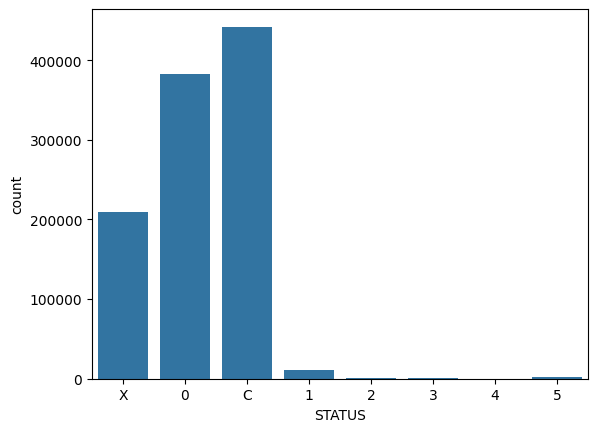

In [43]:
sns.countplot(x='STATUS', data=credit_record_df)
plt.show()

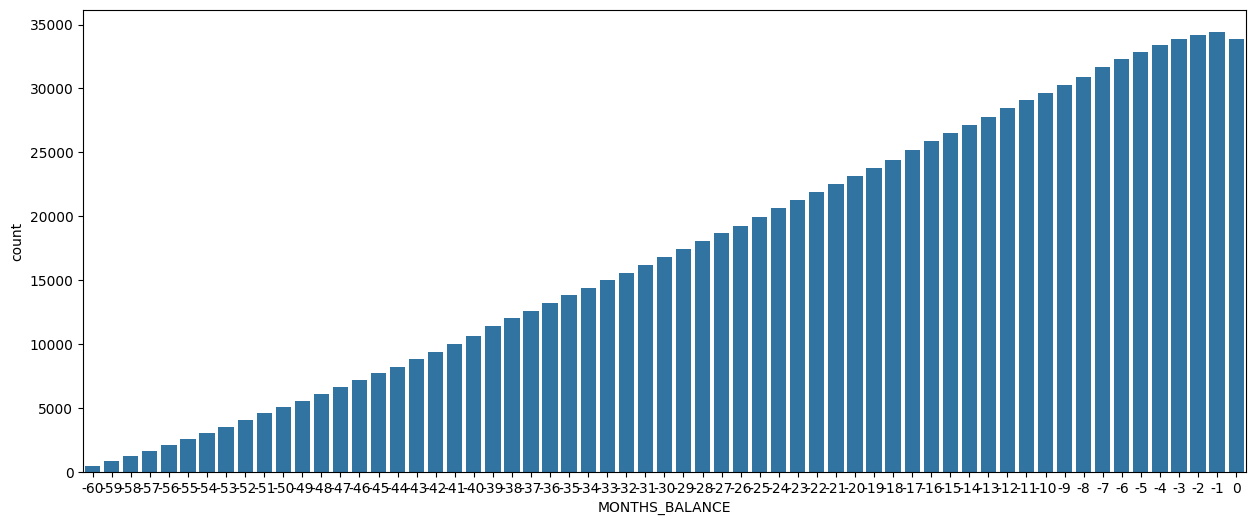

In [44]:
plt.figure(figsize=(15, 6))
sns.countplot(x='MONTHS_BALANCE', data=credit_record_df)
plt.show()

In [45]:
credit_record_df.MONTHS_BALANCE.nunique()

61

In [46]:
credit_record_df.MONTHS_BALANCE.min()# showing when was the last time the client got month money into his account

-60

In [47]:
credit_record_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [48]:
#credit_record_df['MONTHS_BALANCE'].groupby(credit_record_df['STATUS']).median()
credit_record_df['MONTHS_BALANCE'].groupby(credit_record_df['STATUS']).agg(pd.Series.mode)

,MONTHS_BALANCE
STATUS,
0,-3
1,-4
2,"[-18, -3]"
3,"[-17, -2]"
4,-1
5,0
C,0
X,0


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(credit_record_df['MONTHS_BALANCE'], bins=30, kde=True)
plt.title('Distribution of MONTHS_BALANCE')
plt.xlabel('Months Balance')
plt.ylabel('Frequency')
plt.show()

In [50]:
# sns.countplot(data=credit_record_df,x='STATUS', hue=credit_record_df['MONTHS_BALANCE'])

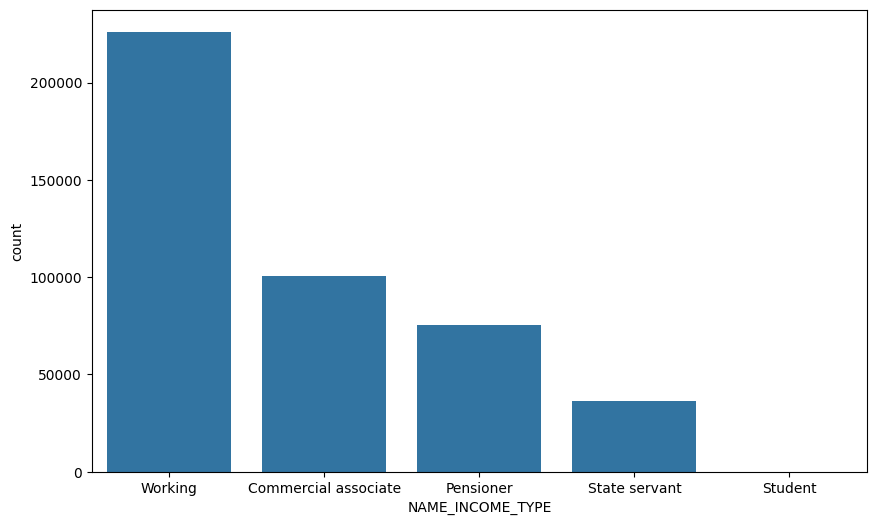

In [51]:
figsize = (10, 6)
plt.figure(figsize=figsize)
sns.countplot(x='NAME_INCOME_TYPE', data=application_record_df)
plt.show()

we are adding new column to categize bank customer into Good and Bad

In [52]:
credit_record_df['Good or Bad'] = ['Good' if x in set(['0','X','C']) else 'Bad' for x in credit_record_df['STATUS']]
credit_record_df

,ID,MONTHS_BALANCE,STATUS,Good or Bad
0,5001711,0,X,Good
1,5001711,-1,0,Good
2,5001711,-2,0,Good
3,5001711,-3,0,Good
4,5001712,0,C,Good
...,...,...,...,...
1048570,5150487,-25,C,Good
1048571,5150487,-26,C,Good
1048572,5150487,-27,C,Good
1048573,5150487,-28,C,Good


In [53]:
credit_goods_bads = credit_record_df.groupby(['ID','Good or Bad']).size().to_frame('size')
credit_goods_bads.reset_index(inplace=True)
credit_goods_bads

,ID,Good or Bad,size
0,5001711,Good,4
1,5001712,Good,19
2,5001713,Good,22
3,5001714,Good,15
4,5001715,Good,60
...,...,...,...
51329,5150482,Good,18
51330,5150483,Good,18
51331,5150484,Good,13
51332,5150485,Good,2


In [54]:
idx = credit_goods_bads.groupby('ID')['size'].idxmax()
max_goods_bads = credit_goods_bads.loc[idx]
max_goods_bads


# print(hello)

,ID,Good or Bad,size
0,5001711,Good,4
1,5001712,Good,19
2,5001713,Good,22
3,5001714,Good,15
4,5001715,Good,60
...,...,...,...
51329,5150482,Good,18
51330,5150483,Good,18
51331,5150484,Good,13
51332,5150485,Good,2


In [55]:
max_goods_bads['Label'] = [1 if x == 'Good' else 0 for x in max_goods_bads['Good or Bad']]
max_goods_bads

,ID,Good or Bad,size,Label
0,5001711,Good,4,1
1,5001712,Good,19,1
2,5001713,Good,22,1
3,5001714,Good,15,1
4,5001715,Good,60,1
...,...,...,...,...
51329,5150482,Good,18,1
51330,5150483,Good,18,1
51331,5150484,Good,13,1
51332,5150485,Good,2,1


In [56]:
max_goods_bads = max_goods_bads.drop(['Good or Bad', 'size'], axis=1)
max_goods_bads = max_goods_bads.reset_index(drop=True)
max_goods_bads

,ID,Label
0,5001711,1
1,5001712,1
2,5001713,1
3,5001714,1
4,5001715,1
...,...,...
45980,5150482,1
45981,5150483,1
45982,5150484,1
45983,5150485,1


#### **Time to join data**

In [57]:
# filling OCCUPATION_TYPE in application data
application_record_df.fillna('Unknown', inplace=True)

In [58]:
len(set(application_record_df['ID']).intersection(set(max_goods_bads['ID'])))

36457

In [59]:
data = pd.merge(application_record_df, max_goods_bads, how='inner', on='ID')
data

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Label
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,1


# **Preprocessing**

## **Feature Selection**

In [60]:
X = data.drop('Label', axis=1)
y = data['Label']
X

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0


### **Mutual Information**

In [61]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [62]:
X_info = X.copy()

# Label encoding for categoricals
for colname in X_info.select_dtypes("object"):
    X_info[colname], _ = X_info[colname].factorize()

# Converting floats to ints
for colname in X_info.select_dtypes("float"):
    X_info[colname] = X_info[colname].astype(int)

# Converting bools to ints
#for colname in X_info.select_dtypes("bool"):
#    X_info[colname] = X_info[colname].astype(int)

# All discrete features should now have integer dtypes
discrete_features = X_info.dtypes != int

In [63]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X_info, y, discrete_features)
mi_scores

,MI Scores
CNT_CHILDREN,0.004482
FLAG_MOBIL,0.003765
ID,0.002891
FLAG_OWN_CAR,0.002733
OCCUPATION_TYPE,0.002172
CNT_FAM_MEMBERS,0.001532
NAME_EDUCATION_TYPE,0.000274
CODE_GENDER,0.000000
AMT_INCOME_TOTAL,0.000000
FLAG_OWN_REALTY,0.000000


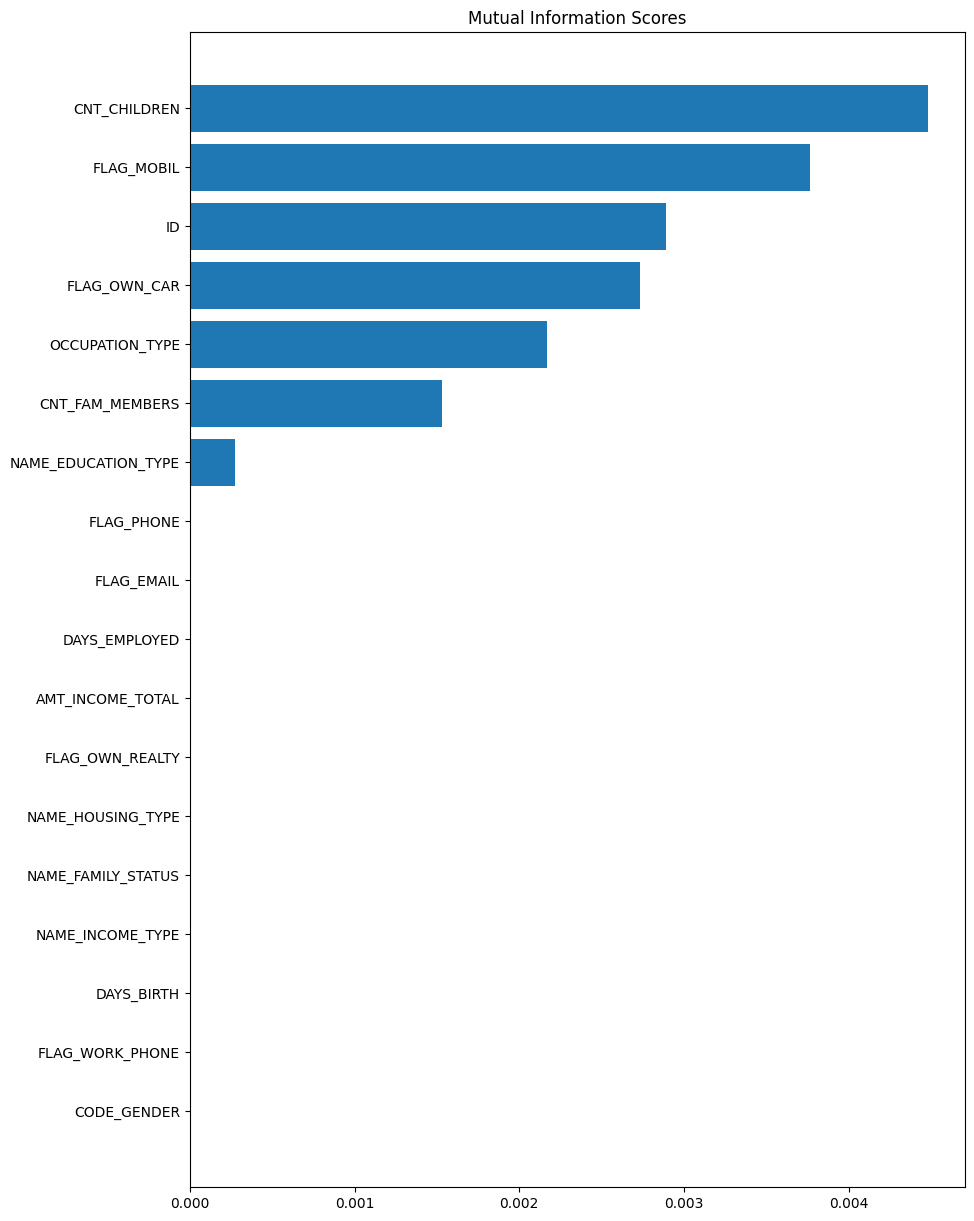

In [64]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(10, 15))
plot_mi_scores(mi_scores)

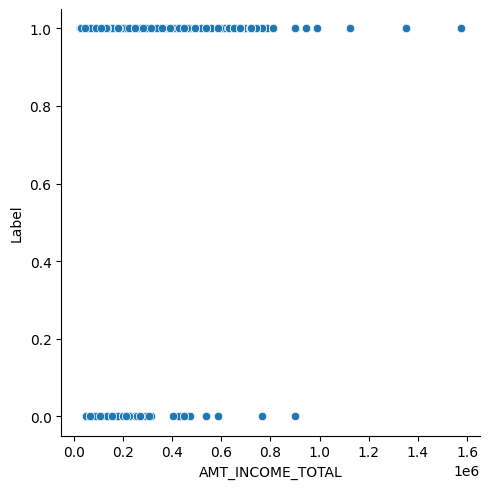

In [65]:
sns.relplot(x="AMT_INCOME_TOTAL", y="Label", data=data);

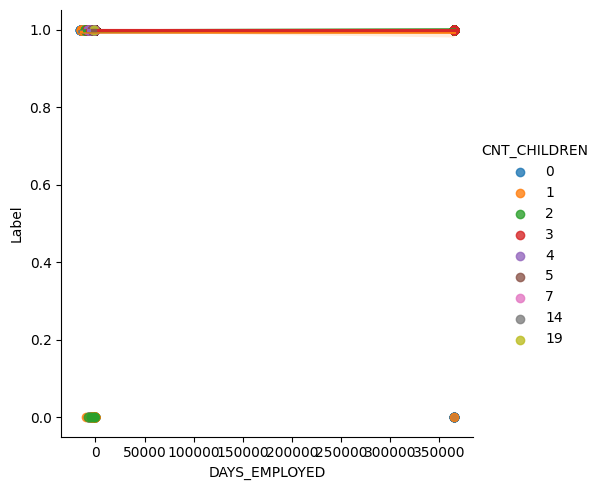

In [66]:
sns.lmplot(x="DAYS_EMPLOYED", y="Label", hue="CNT_CHILDREN", data=data);

<Axes: xlabel='OCCUPATION_TYPE', ylabel='Label'>

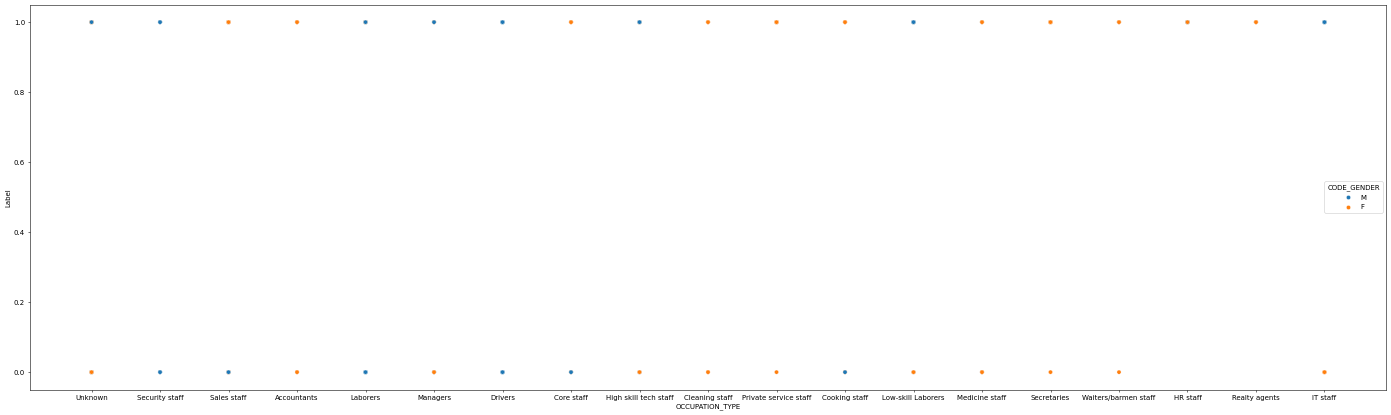

In [67]:
#sns.lmplot(x="CODE_GENDER", y=y, hue="FLAG_OWN_REALTY", data=X_info);
plt.figure(dpi=50, figsize=(35, 10))
sns.scatterplot(x=data['OCCUPATION_TYPE'], y=data['Label'], hue=data['CODE_GENDER'])

## **Covert Categorical Data To Numerical**

In [68]:
X = pd.get_dummies(X, drop_first=True)
X

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff
0,5008804,0,427500.0,-12005,-4542,1,1,0,0,2.0,...,False,False,False,False,False,False,False,False,True,False
1,5008805,0,427500.0,-12005,-4542,1,1,0,0,2.0,...,False,False,False,False,False,False,False,False,True,False
2,5008806,0,112500.0,-21474,-1134,1,0,0,0,2.0,...,False,False,False,False,False,False,False,True,False,False
3,5008808,0,270000.0,-19110,-3051,1,0,1,1,1.0,...,False,False,False,False,False,True,False,False,False,False
4,5008809,0,270000.0,-19110,-3051,1,0,1,1,1.0,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,0,315000.0,-17348,-2420,1,0,0,0,2.0,...,False,True,False,False,False,False,False,False,False,False
36453,5149834,0,157500.0,-12387,-1325,1,0,1,1,2.0,...,False,False,True,False,False,False,False,False,False,False
36454,5149838,0,157500.0,-12387,-1325,1,0,1,1,2.0,...,False,False,True,False,False,False,False,False,False,False
36455,5150049,0,283500.0,-17958,-655,1,0,0,0,2.0,...,False,False,False,False,False,True,False,False,False,False


## **Scalling the Data**

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Normalized input data(X):\n", X_train_scaled)

Normalized input data(X):
 [[-0.98470504 -0.58068211 -0.51169961 ... -0.12714828 -0.66952
  -0.06613304]
 [-0.80341846  0.7672639  -0.51169961 ... -0.12714828 -0.66952
  -0.06613304]
 [ 0.02026148  2.11520992 -0.06794722 ... -0.12714828 -0.66952
  -0.06613304]
 ...
 [-0.72977527 -0.58068211 -1.08857771 ... -0.12714828 -0.66952
  -0.06613304]
 [-1.63415189 -0.58068211 -0.28982341 ... -0.12714828  1.49360737
  -0.06613304]
 [-0.37298837 -0.58068211  3.92582424 ... -0.12714828  1.49360737
  -0.06613304]]


# **Modeling**

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [77]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Random Forest Confusion Matrix
[[   3   31]
 [  19 7239]]


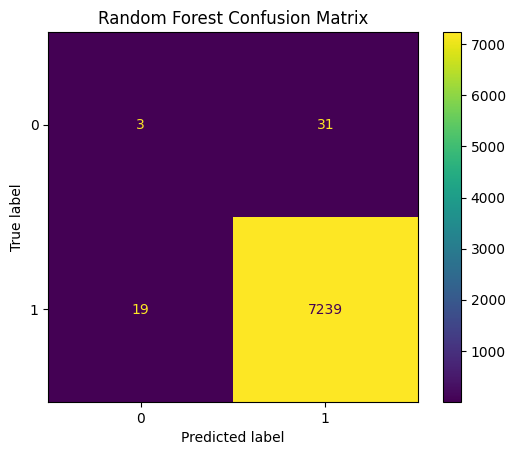

In [78]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix")
print(rf_cm)

ConfusionMatrixDisplay(confusion_matrix=rf_cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [79]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:36:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Confusion Matrix
[[   4   30]
 [   8 7250]]


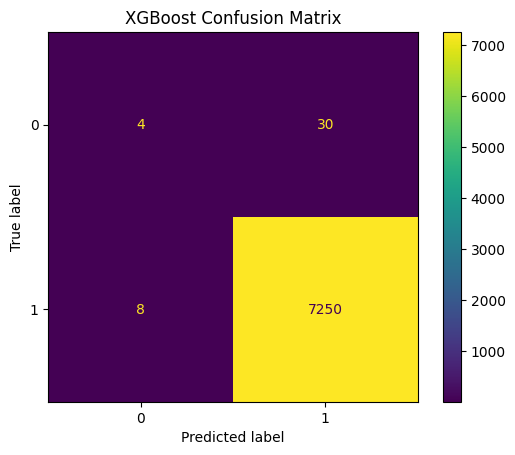

In [80]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

print("XGBoost Confusion Matrix")
print(xgb_cm)

ConfusionMatrixDisplay(confusion_matrix=xgb_cm).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

### **Using Stratified K-Fold with Decision Tree Classifier**

In [82]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# clf = DecisionTreeClassifier(random_state=42)

# sk_folds = StratifiedKFold(n_splits=10)

# # Cross-validation accuracy scores
# scores = cross_val_score(clf, X_train_scaled, y_train, cv=sk_folds)

# print("Cross Validation Scores:", scores)
# print("Average CV Score:", scores.mean())
# print("Number of CV Scores used in Average:", len(scores))

# # Get predictions using cross validation
# y_pred = cross_val_predict(clf, X_train_scaled, y_train, cv=sk_folds)

# # Confusion Matrix
# cm = confusion_matrix(y_train, y_pred)

# print("Confusion Matrix:")
# print(cm)

# # Plot confusion matrix
# ConfusionMatrixDisplay(confusion_matrix=cm).plot()
# plt.title("Decision Tree Confusion Matrix (10-fold CV)")
# plt.show()